,Zone,District,Urban_Rural,Total_Population,Male,Female,Literacy_Rate_Total,Literacy_Rate_Male,Literacy_Rate_Female,Literacy_Rate_Youth,Households_Total,Households_with_Electricity,Households_with_Radio,Households_with_TV,Households_with_Telephone,Electricity_Access_Rate,Radio_Access_Rate,TV_Access_Rate,Telephone_Access_Rate
0,Janakpur,Dhanusha,Urban,120000,60000,60000,66,72,60,82,22000,18000,9000,12000,8500,81.818182,40.909091,54.545455,38.636364
1,Janakpur,Dhanusha,Rural,260000,130000,130000,59,65,53,77,48000,26000,23000,10000,7000,54.166667,47.916667,20.833333,14.583333
2,Janakpur,Mahottari,Urban,90000,45000,45000,64,70,58,80,18000,15000,7000,9500,6000,83.333333,38.888889,52.777778,33.333333
3,Janakpur,Mahottari,Rural,210000,105000,105000,57,63,51,74,42000,22000,20000,8000,5000,52.380952,47.619048,19.047619,11.904762
4,Janakpur,Sarlahi,Urban,100000,50000,50000,65,71,59,81,20000,16000,8000,11000,7000,80.000000,40.000000,55.000000,35.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Zone                         16 non-null     object 
 1   District                     16 non-null     object 
 2   Urban_Rural                  16 non-null     object 
 3   Total_Population             16 non-null     int64  
 4   Male                         16 non-null     int64  
 5   Female                       16 non-null     int64  
 6   Literacy_Rate_Total          16 non-null     int64  
 7   Literacy_Rate_Male           16 non-null     int64  
 8   Literacy_Rate_Female         16 non-null     int64  
 9   Literacy_Rate_Youth          16 non-null     int64  
 10  Households_Total             16 non-null     int64  
 11  Households_with_Electricity  16 non-null     int64  
 12  Households_with_Radio        16 non-null     int64  
 13  Households_with_TV    

None

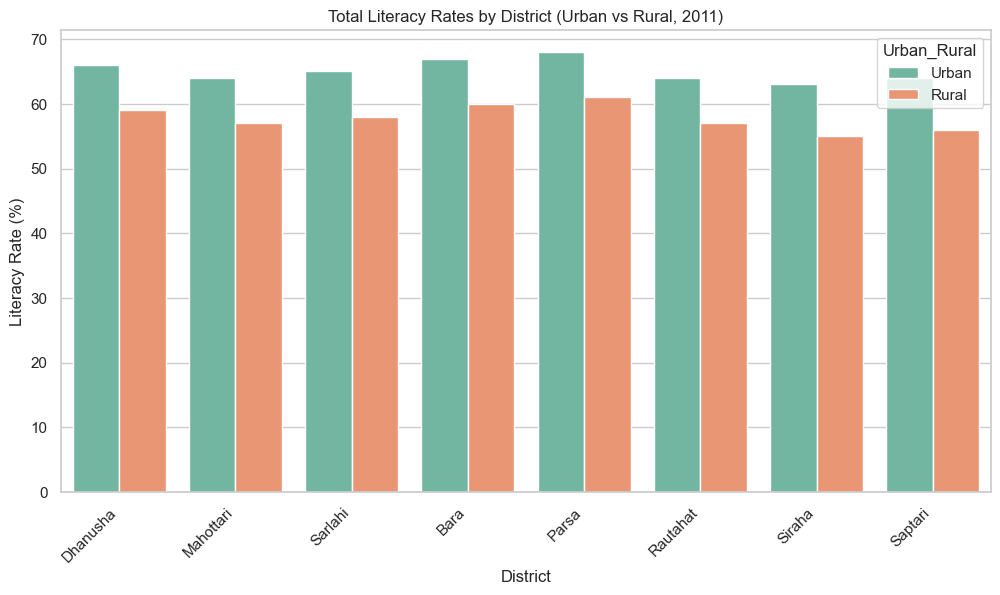

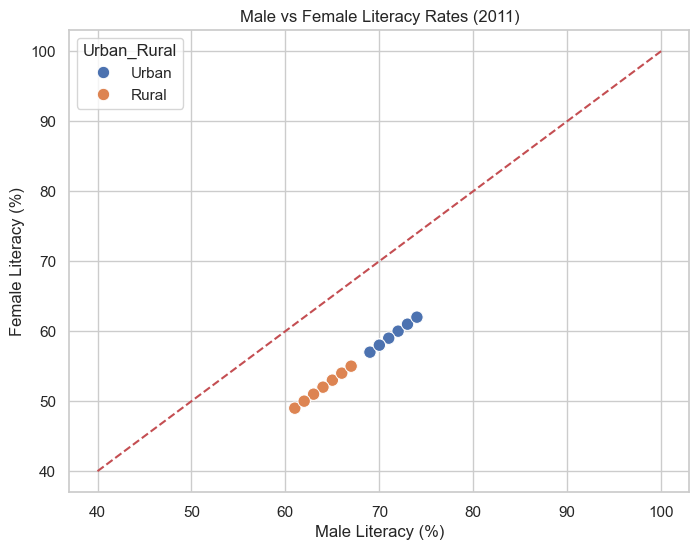

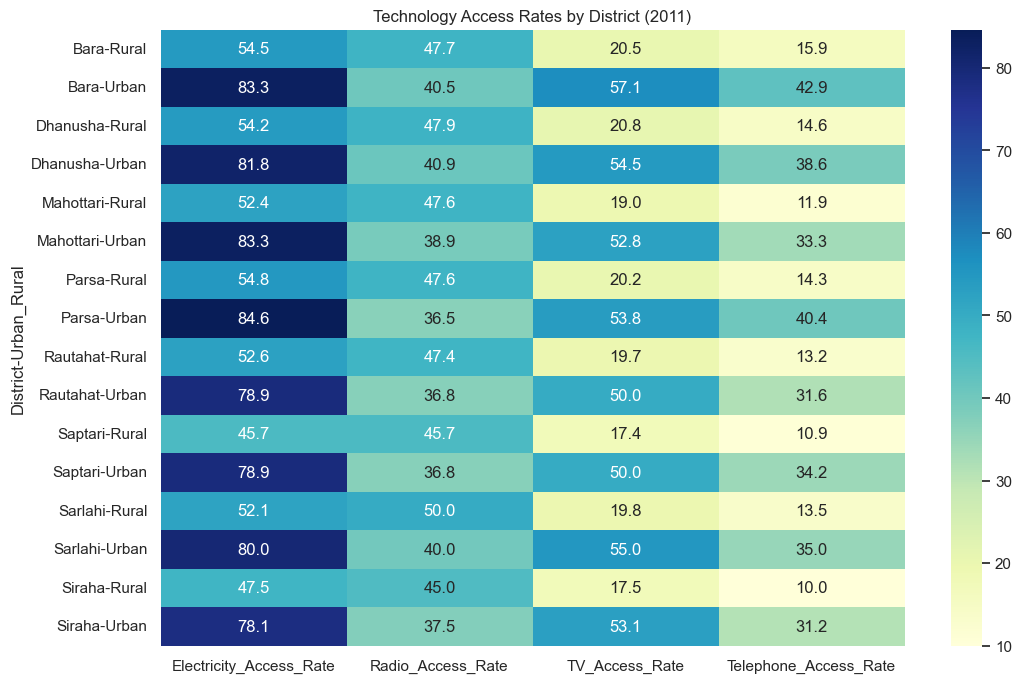

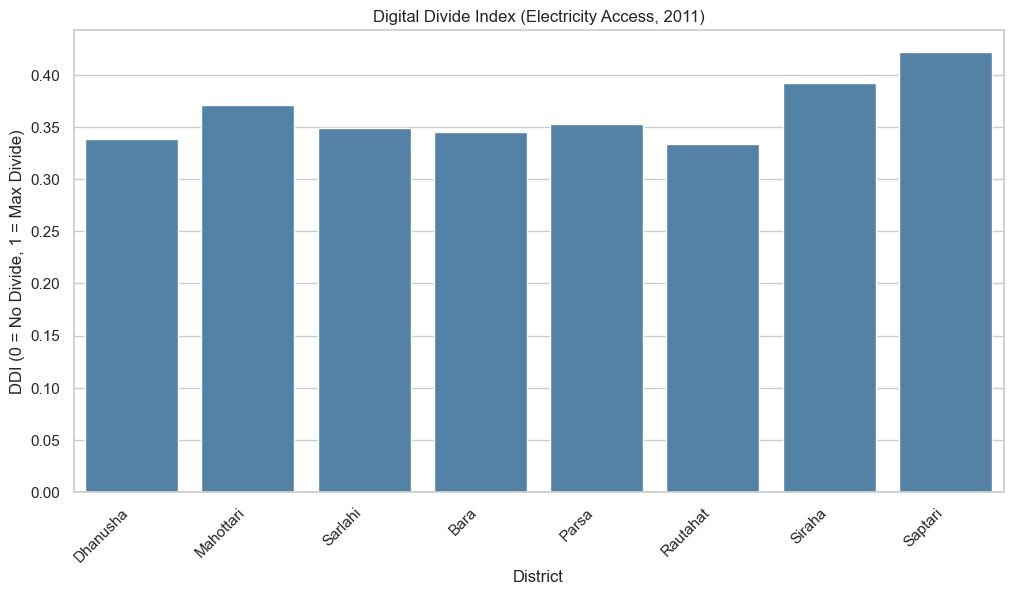

In [2]:
# visualize_2011.ipynb

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# -------------------------------
# Load processed 2011 dataset
# -------------------------------
df_2011 = pd.read_csv("../data_processed/df_2011.csv")
display(df_2011.head())
display(df_2011.info())

# 
# 1. Literacy Rates (Urban vs Rural)
# 
plt.figure(figsize=(12,6))
sns.barplot(data=df_2011, x="District", y="Literacy_Rate_Total",
            hue="Urban_Rural", palette="Set2")
plt.xticks(rotation=45, ha="right")
plt.title("Total Literacy Rates by District (Urban vs Rural, 2011)")
plt.ylabel("Literacy Rate (%)")
plt.show()

# -------------------------------
# 2. Gender Gap in Literacy
# -------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_2011, 
                x="Literacy_Rate_Male", 
                y="Literacy_Rate_Female", 
                hue="Urban_Rural", s=80)
plt.plot([40,100],[40,100],'r--')  # equality line
plt.title("Male vs Female Literacy Rates (2011)")
plt.xlabel("Male Literacy (%)")
plt.ylabel("Female Literacy (%)")
plt.show()

# -------------------------------
# 3. Technology Access Heatmap
# -------------------------------
tech_cols = ["Electricity_Access_Rate","Radio_Access_Rate",
             "TV_Access_Rate","Telephone_Access_Rate"]

tech_df = df_2011.pivot_table(values=tech_cols, 
                              index=["District","Urban_Rural"])

plt.figure(figsize=(12,8))
sns.heatmap(tech_df, annot=True, cmap="YlGnBu", fmt=".1f")
plt.title("Technology Access Rates by District (2011)")
plt.show()

# -------------------------------
# 4. Digital Divide Index (DDI)
# -------------------------------
ddi_list = []
for district in df_2011["District"].unique():
    urban = df_2011[(df_2011["District"]==district) & (df_2011["Urban_Rural"]=="Urban")]
    rural = df_2011[(df_2011["District"]==district) & (df_2011["Urban_Rural"]=="Rural")]
    if not urban.empty and not rural.empty:
        ddi_elec = 1 - (rural["Electricity_Access_Rate"].values[0] / 
                        urban["Electricity_Access_Rate"].values[0])
        ddi_tv = 1 - (rural["TV_Access_Rate"].values[0] / 
                      urban["TV_Access_Rate"].values[0])
        ddi_list.append({"District": district, 
                         "DDI_Electricity": ddi_elec,
                         "DDI_TV": ddi_tv})

ddi_df = pd.DataFrame(ddi_list)

plt.figure(figsize=(12,6))
sns.barplot(data=ddi_df, x="District", y="DDI_Electricity", color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.title("Digital Divide Index (Electricity Access, 2011)")
plt.ylabel("DDI (0 = No Divide, 1 = Max Divide)")
plt.show()


# -------------------------------
# 5. Digital Access Doughnut Diagram - Dhanusha Urban
# -------------------------------
import matplotlib.pyplot as plt

# Filter Dhanusha Urban data
dhanusha_urban = df_2011[
    (df_2011["District"] == "Dhanusha") & 
    (df_2011["Urban_Rural"] == "Urban")
]

# Safety check
if not dhanusha_urban.empty:
    # Extract relevant values dynamically
    values = [
        dhanusha_urban["Electricity_Access_Rate"].values[0],
        dhanusha_urban["Radio_Access_Rate"].values[0],
        dhanusha_urban["TV_Access_Rate"].values[0],
        dhanusha_urban["Telephone_Access_Rate"].values[0],
        dhanusha_urban["Internet_Access_Rate"].values[0] if "Internet_Access_Rate" in dhanusha_urban.columns else 0
    ]

    labels = [
        "Households with Electricity",
        "Households with Radio",
        "Households with TV",
        "Households with Telephone",
        "Households with Internet"
    ]

    # Choose colors (smooth gradient)
    colors = plt.cm.PuBuGn_r([0.15, 0.35, 0.55, 0.75, 0.95])

    # Create figure
    fig, ax = plt.subplots(figsize=(8, 8))

    # Doughnut chart
    wedges, texts, autotexts = ax.pie(
        values,
        labels=labels,
        autopct="%1.1f%%",
        startangle=140,
        colors=colors,
        pctdistance=0.85,
        wedgeprops=dict(width=0.4, edgecolor="white"),
        textprops=dict(color="black", fontsize=10, fontweight="bold")
    )

    # Add white circle for doughnut effect
    centre_circle = plt.Circle((0, 0), 0.70, fc="white")
    ax.add_artist(centre_circle)

    # Title and layout
    ax.set_title(
        "Digital Access Distribution - Dhanusha Urban (2011)",
        fontsize=15,
        fontweight="bold",
        pad=25
    )

    plt.tight_layout()

    # Save to reports folder
    plt.savefig("../reports/doughnut_dhanusha_urban_2011.png", dpi=300, bbox_inches="tight")

    # Display chart
    plt.show()

else:
    print("⚠️ Dhanusha Urban data not found in the dataset.")


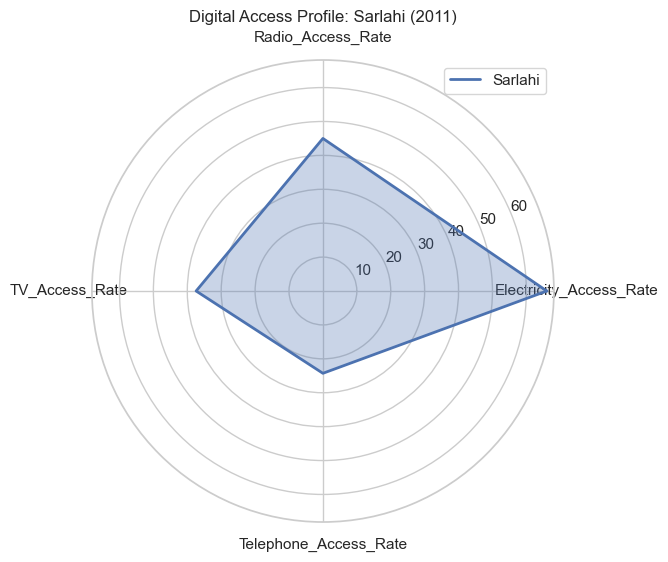

In [ ]:
from math import pi

# Select one district example
district = "Sarlahi"
subset = df_2011[df_2011["District"] == district].groupby("District")[["Electricity_Access_Rate","Radio_Access_Rate","TV_Access_Rate","Telephone_Access_Rate"]].mean()

categories = list(subset.columns)
values = subset.iloc[0].tolist()
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
values += values[:1]
angles += angles[:1]

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
plt.xticks(angles[:-1], categories)

ax.plot(angles, values, linewidth=2, linestyle="solid", label=district)
ax.fill(angles, values, alpha=0.3)
plt.title(f"Digital Access Profile: {district} (2011)")
plt.legend()
plt.show()


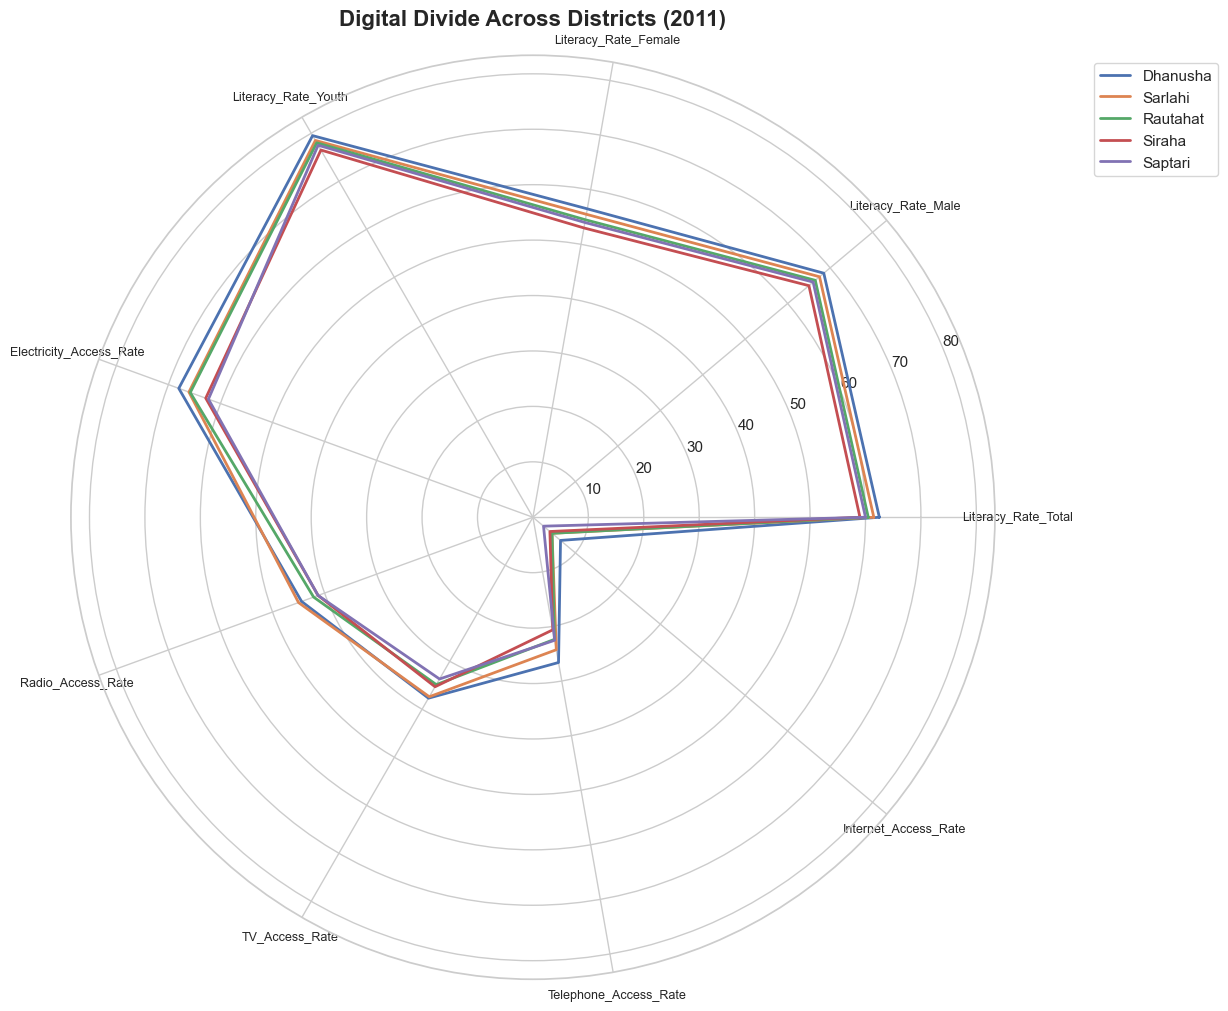

In [ ]:
from math import pi
import matplotlib.pyplot as plt

# Extended categories including Internet
categories = [
    "Literacy_Rate_Total",
    "Literacy_Rate_Male",
    "Literacy_Rate_Female",
    "Literacy_Rate_Youth",
    "Electricity_Access_Rate",
    "Radio_Access_Rate",
    "TV_Access_Rate",
    "Telephone_Access_Rate",
    "Internet_Access_Rate"   # <- Added
]

# If 'Internet_Access_Rate' is not in dataset, create a placeholder (example only)
if "Internet_Access_Rate" not in df_2011.columns:
    import numpy as np
    df_2011["Internet_Access_Rate"] = np.random.randint(1, 10, df_2011.shape[0])  
    # replace with real values if available!

districts = ["Dhanusha","Sarlahi","Rautahat","Siraha","Saptari"]
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(12,12))

for district in districts:
    subset = df_2011[df_2011["District"] == district][categories].mean().tolist()
    subset += subset[:1]  # close loop
    plt.polar(angles, subset, label=district, linewidth=2)

plt.xticks(angles[:-1], categories, fontsize=9)
plt.title("Digital Divide Across Districts (2011)", size=16, weight="bold")
plt.legend(bbox_to_anchor=(1.25, 1))
plt.show()


In [ ]:
# visualize_2011.ipynb - Jupyter Notebook for Visualizing Digital Divide in Nepal (2011 Data)
# This notebook processes 2011 census data on technology access to create doughnut charts
# showing urban-rural internet access splits by zone.

# Cell 1: Install required libraries (if needed)
# !pip install pandas matplotlib

# Cell 2: Import libraries and load data
import pandas as pd
import matplotlib.pyplot as plt

# Load the 2011 CSV file from the specified path under DIGITAL_DIVIDE/data_processed/
# Assumes the notebook is run from notebooks/ directory, so relative path to parent data_processed/
df = pd.read_csv('../data_processed/df_2011.csv')

# Preview the data
print(df.head())
print(df.describe())

# Cell 3: Process and aggregate data
# Focus on Internet_Access_Rate for digital divide visualization
# Aggregate by Zone: Calculate weighted average Internet access rate (weighted by Total_Population)
df['Weighted_Internet_Access'] = df['Internet_Access_Rate'] * df['Total_Population']
zone_aggregated = df.groupby('Zone').agg({
    'Total_Population': 'sum',
    'Weighted_Internet_Access': 'sum'
}).reset_index()

# Calculate overall weighted Internet access rate per zone
zone_aggregated['Internet_Access_Rate_Weighted'] = (zone_aggregated['Weighted_Internet_Access'] / zone_aggregated['Total_Population']) * 100

# For each zone, calculate urban vs rural proportions of access
# First, get urban and rural populations and weighted access per zone
urban_data = df[df['Urban_Rural'] == 'Urban'].groupby('Zone').agg({
    'Total_Population': 'sum',
    'Weighted_Internet_Access': 'sum'
}).reset_index()
urban_data['Urban_Access_Rate'] = (urban_data['Weighted_Internet_Access'] / urban_data['Total_Population']) * 100

rural_data = df[df['Urban_Rural'] == 'Rural'].groupby('Zone').agg({
    'Total_Population': 'sum',
    'Weighted_Internet_Access': 'sum'
}).reset_index()
rural_data['Rural_Access_Rate'] = (rural_data['Weighted_Internet_Access'] / rural_data['Total_Population']) * 100

# Merge for easy plotting
zone_summary = pd.merge(urban_data[['Zone', 'Urban_Access_Rate']], 
                        rural_data[['Zone', 'Rural_Access_Rate']], on='Zone')

print(zone_summary)  # Preview the aggregated data

# Save processed data to data_processed/ (optional; comment out if not needed)
# zone_summary.to_csv('../data_processed/zone_internet_summary_2011.csv', index=False)
# zone_aggregated.to_csv('../data_processed/zone_aggregated_2011.csv', index=False)

# Cell 4: Create Doughnut Charts for each Zone
# Function to create a doughnut chart
def create_doughnut(ax, labels, sizes, title, colors=['#ff9999', '#66b3ff']):
    wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%', 
                                      colors=colors, startangle=90, 
                                      wedgeprops=dict(width=0.5, edgecolor='w'))
    ax.set_title(title)
    # Improve text visibility
    for autotext in autotexts:
        autotext.set_color('white')
    return wedges, texts, autotexts

# Create subplots for each zone (adjust n_cols if more/less zones)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

zones = zone_summary['Zone'].tolist()
for i, zone in enumerate(zones):
    urban_rate = zone_summary.loc[zone_summary['Zone'] == zone, 'Urban_Access_Rate'].values[0]
    rural_rate = zone_summary.loc[zone_summary['Zone'] == zone, 'Rural_Access_Rate'].values[0]
    total_pop = zone_aggregated.loc[zone_aggregated['Zone'] == zone, 'Total_Population'].values[0]
    urban_pop = urban_data.loc[urban_data['Zone'] == zone, 'Total_Population'].values[0]
    
    # Proportions: Urban access contribution vs Rural gap (as % of total weighted access potential)
    # Urban prop: weighted urban access share
    urban_prop = (urban_rate * urban_pop / total_pop) * 100
    rural_prop = 100 - urban_prop  # Represents the divide/gap
    
    create_doughnut(axes[i], ['Urban Access', 'Rural Gap'], [urban_prop, rural_prop], 
                    f'{zone} Zone (2011): Internet Access Split', colors=['#4CAF50', '#f44336'])

plt.tight_layout()
# plt.savefig('../reports/internet_doughnut_by_zone_2011.png', dpi=300, bbox_inches='tight')  # Commented out to avoid saving
plt.show()

# Cell 5: Overall Doughnut for Entire Region
overall_urban_rate = (urban_data['Urban_Access_Rate'] * urban_data['Total_Population']).sum() / urban_data['Total_Population'].sum()
overall_rural_rate = (rural_data['Rural_Access_Rate'] * rural_data['Total_Population']).sum() / rural_data['Total_Population'].sum()
total_pop_all = zone_aggregated['Total_Population'].sum()
urban_pop_all = urban_data['Total_Population'].sum()
overall_urban_prop = (overall_urban_rate * urban_pop_all / total_pop_all) * 100
overall_rural_prop = 100 - overall_urban_prop

fig2, ax2 = plt.subplots(figsize=(8, 8))
create_doughnut(ax2, ['Urban Access', 'Rural Gap'], [overall_urban_prop, overall_rural_prop], 
                'Overall Region (2011): Internet Access Divide', colors=['#4CAF50', '#f44336'])

# plt.savefig('../reports/overall_internet_doughnut_2011.png', dpi=300, bbox_inches='tight')  # Commented out to avoid saving
plt.show()

# Cell 6: Additional Analysis - Compare with Other Metrics (e.g., Telephone Access)
# Repeat similar processing for Telephone_Access_Rate
df['Weighted_Telephone_Access'] = df['Telephone_Access_Rate'] * df['Total_Population']
# To create similar charts, duplicate the aggregation and plotting code, replacing 'Internet' with 'Telephone'

print("Visualization complete! Plots displayed inline below the code cells.")

